# Проект - Маркетинг

**Описание**
  
Интернет-магазин собирает историю покупателей, проводит рассылки предложений и
планирует будущие продажи. Для оптимизации процессов надо выделить пользователей,
которые готовы совершить покупку в ближайшее время.

**Цель**

Предсказать вероятность покупки в течение 90 дней

**Задачи**
 - Изучить данные
 - Разработать полезные признаки
 - Создать модель для классификации пользователей
 - Улучшить модель и максимизировать метрику roc_auc
 - Выполнить тестирование

### Описание данных

`apparel-purchases`

Данные о покупках клиентов по дням и по товарам. В каждой записи покупка определенного товара, его цена, количество штук.
В таблице есть списки идентификаторов, к каким категориям относится товар.
Часто это вложенные категории (например автотовары-аксессуары-освежители), но также может включать в начале списка маркер распродажи или маркер женщинам/мужчинам.
Нумерация категорий сквозная для всех уровней, то есть 44 на второй позиции списка или на третьей – это одна и та же категория. Иногда дерево категорий обновляется, поэтому могут меняться вложенности, например ['4', '28', '44', '1594'] или ['4', '44', '1594'].
Как обработать такие случаи – можете предлагать свои варианты решения.
 - client_id идентификатор клиента
 - quantity количество единиц товара
 - price цена товара
 - category_ids идентификаторы категорий
 - date дата покупки
 - message_id идентификатор сообщения из рассылки

`apparel-messages`

Рассылки, которые были отправлены клиентам из таблицы покупок.
 - bulk_campaign_id идентификатор рассылки
 - client_id идентификатор клиента
 - message_id идентификатор сообщения
 - event действие с сообщением (отправлено, открыто, покупка…)
 - channel канал рассылки
 - date дата действия
 - created_at дата-время полностью

`target`

 - client_id идентификатор клиента
 - target клиент совершил покупку в целевом периоде

Общая база рассылок огромна, поэтому собрали для вас агрегированную по дням статистику по рассылкам.
Если будете создавать на основе этой статистики дополнительныепризнаки, обратите внимание, что нельзя суммировать по колонкам nunique, потому что это уникальные клиенты в пределах дня, у вас нет данных, повторяются ли они в другие дни)

## Импорт библиотек

In [1]:
# !pip install seaborn -q
# !pip install phik -q
# !pip install catboost -q
# !pip install lightgbm -q
# !pip install scikit-learn -q
# !pip install matplotlib_venn -q
# !pip install networkx -q

In [2]:
# математика
import pandas as pd
import numpy as np

# графики
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import plotly.graph_objects as go
import plotly.express as px
import networkx as nx

# для преобразования списка_как_строка в список
import ast

# для подсчета статистических данных в списках
import statistics

# для подсчёта корреляции между признаками разных типов данных
from phik import phik_matrix
from phik.report import plot_correlation_matrix

# модели градиентного бустинга
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# ансамблевая модель МО
from sklearn.ensemble import RandomForestClassifier

# Пайплайны
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# дополнительные классы для преобразования данных
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler

from sklearn.model_selection import GridSearchCV

# разделение дафрейма на тестовые и тренировочные данные
from sklearn.model_selection import train_test_split

# для преобразования списка_как_строка в список
import ast

# метрики
from sklearn.metrics import roc_auc_score

## Системные настройки

In [3]:
RANDOM_STATE = 42
TEST_SIZE    = 0.2

## Функции

In [4]:
DATETIME_COLUMNS = []
ID = 'client_id'

def visualize(dataframe: pd.DataFrame) -> None:
    """
    Принимает на вход датафрейм.
    Выводит графики для статистичесого анализа.
    Не возвращает ничего.
    """
    try:
        for column in dataframe.columns:
            if column in DATETIME_COLUMNS:
                pass
            if column == ID:
                print(f'-----------------------------------------------------------')
                print(f'Анализ уникальных идентификаторов: {column}')
                unique_ids = dataframe[ID].nunique()
                print(f'Уникальных ID: {unique_ids} из {len(dataframe)} записей')
            elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
                print(f'-----------------------------------------------------------')
                print(f'Распределение категориальной величины: {column}')
                plt.figure(figsize=(12, 6))
                dataframe[column].value_counts(ascending=True).plot.bar()
                plt.title(column)
                plt.show()
            # числовые данные
            elif pd.api.types.is_numeric_dtype(dataframe[column]):
                print(f'-----------------------------------------------------------')
                print(f'Распределение числовой величины: {column}')
                print(dataframe[column].describe())
                plt.figure(figsize=(12, 6))
                dataframe[column].hist(bins=100, alpha=0.5)
                plt.title(column)
                plt.show()

                dataframe.boxplot(column=[column])
                plt.title(column, fontsize=14, pad=20)
                plt.show()
            else:
                print(f'-----------------------------------------------------------')
                print(f'Тип данных в столбце {column} : {dataframe[column].dtype}')
    except Exception as e:
        print(f'Cant proceed column {column}. Error: {e}')

In [5]:
def display_missing(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
        Принимает на вход датафрейм.
        Возвращает датафрейм с информацией о пропусках.
    """
    try:
        temp    = dataframe.copy()
        missing = (
            pd.DataFrame(
                {
                    'Кол-во пропусков': temp.isnull().sum(),
                    'Доля пропусков %': temp.isnull().mean().round(4) * 100
                }
            ).style.background_gradient(cmap='coolwarm')
        )
    except Exception as e:
        print(f'Error: {e}')
    
    return(missing)

## Загрузка данных

In [6]:
df_apparel_purchases     = pd.read_csv('./data/apparel-purchases.csv')
df_apparel_messages      = pd.read_csv('./data/apparel-messages.csv')
df_apparel_target_binary = pd.read_csv('./data/apparel-target_binary.csv')

In [7]:
df_apparel_purchases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202208 entries, 0 to 202207
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   client_id     202208 non-null  int64  
 1   quantity      202208 non-null  int64  
 2   price         202208 non-null  float64
 3   category_ids  202208 non-null  object 
 4   date          202208 non-null  object 
 5   message_id    202208 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 9.3+ MB


In [8]:
df_apparel_purchases.head(5)

,client_id,quantity,price,category_ids,date,message_id
0,1515915625468169594,1,1999.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1,1515915625468169594,1,2499.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
2,1515915625471138230,1,6499.0,"['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843
3,1515915625471138230,1,4999.0,"['4', '28', '244', '432']",2022-05-16,1515915625471138230-4437-6282242f27843
4,1515915625471138230,1,4999.0,"['4', '28', '49', '413']",2022-05-16,1515915625471138230-4437-6282242f27843


In [9]:
df_apparel_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12739798 entries, 0 to 12739797
Data columns (total 7 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   bulk_campaign_id  int64 
 1   client_id         int64 
 2   message_id        object
 3   event             object
 4   channel           object
 5   date              object
 6   created_at        object
dtypes: int64(2), object(5)
memory usage: 680.4+ MB


In [10]:
df_apparel_messages.head(5)

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
0,4439,1515915625626736623,1515915625626736623-4439-6283415ac07ea,open,email,2022-05-19,2022-05-19 00:14:20
1,4439,1515915625490086521,1515915625490086521-4439-62834150016dd,open,email,2022-05-19,2022-05-19 00:39:34
2,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,open,email,2022-05-19,2022-05-19 00:51:49
3,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,click,email,2022-05-19,2022-05-19 00:52:20
4,4439,1515915625471518311,1515915625471518311-4439-628341570c133,open,email,2022-05-19,2022-05-19 00:56:52


In [11]:
df_apparel_target_binary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   client_id  49849 non-null  int64
 1   target     49849 non-null  int64
dtypes: int64(2)
memory usage: 779.0 KB


In [12]:
df_apparel_target_binary.head(5)

,client_id,target
0,1515915625468060902,0
1,1515915625468061003,1
2,1515915625468061099,0
3,1515915625468061100,0
4,1515915625468061170,0


## Преобразуем даты

In [13]:
df_apparel_purchases['date'] = pd.to_datetime(df_apparel_purchases['date'], format="%Y-%m-%d")
df_apparel_messages['date']  = pd.to_datetime(df_apparel_messages['date'], format="%Y-%m-%d")

## Пропуски

In [14]:
display_missing(df_apparel_messages)

,Кол-во пропусков,Доля пропусков %
bulk_campaign_id,0,0.000000
client_id,0,0.000000
message_id,0,0.000000
event,0,0.000000
channel,0,0.000000
date,0,0.000000
created_at,0,0.000000


In [15]:
display_missing(df_apparel_purchases)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
quantity,0,0.000000
price,0,0.000000
category_ids,0,0.000000
date,0,0.000000
message_id,0,0.000000


In [16]:
display_missing(df_apparel_target_binary)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000


## Полные дубликаты

In [17]:
df_apparel_messages_dup_sum      = df_apparel_messages.duplicated().sum()
df_apparel_messages_shape_0      = df_apparel_messages.shape[0]
df_apparel_purchases_dup_sum     = df_apparel_purchases.duplicated().sum()
df_apparel_purchases_shape_0     = df_apparel_purchases.shape[0]
df_apparel_target_binary_dup_sum = df_apparel_target_binary.duplicated().sum()
df_apparel_target_binary_shape_0 = df_apparel_target_binary.shape[0]


print(f'df_apparel_messages - кол-во полных дубликатов строк: {df_apparel_messages_dup_sum}')
print(f'df_apparel_messages - всего строк: {df_apparel_messages_shape_0}')
print(f'df_apparel_messages - процент дубликатов: {(df_apparel_messages_dup_sum / df_apparel_messages_shape_0 * 100):.2f}')
print('\n')

print(f'df_apparel_purchases - кол-во полных дубликатов строк: {df_apparel_purchases_dup_sum}')
print(f'df_apparel_purchases - всего строк: {df_apparel_purchases_shape_0}')
print(f'df_apparel_purchases - процент дубликатов: {(df_apparel_purchases_dup_sum / df_apparel_purchases_shape_0 * 100):.2f}')
print('\n')

print(f'df_apparel_target_binary - кол-во полных дубликатов строк: {df_apparel_target_binary_dup_sum}')
print(f'df_apparel_target_binary - всего строк: {df_apparel_target_binary_shape_0}')
print(f'df_apparel_target_binary - процент дубликатов: {(df_apparel_target_binary_dup_sum / df_apparel_target_binary_shape_0 * 100):.2f}')

df_apparel_messages - кол-во полных дубликатов строк: 48610
df_apparel_messages - всего строк: 12739798
df_apparel_messages - процент дубликатов: 0.38


df_apparel_purchases - кол-во полных дубликатов строк: 73020
df_apparel_purchases - всего строк: 202208
df_apparel_purchases - процент дубликатов: 36.11


df_apparel_target_binary - кол-во полных дубликатов строк: 0
df_apparel_target_binary - всего строк: 49849
df_apparel_target_binary - процент дубликатов: 0.00


### удалим полные дубликаты

In [18]:
df_apparel_messages.drop_duplicates(inplace=True)
df_apparel_purchases.drop_duplicates(inplace=True)

## Изучаем данные

In [19]:
print(f"Нижняя дата для df_apparel_purchases: {df_apparel_purchases['date'].min()}")
print(f"Верхняя дата для df_apparel_purchases: {df_apparel_purchases['date'].max()}")
print('\n')
print(f"Нижняя дата для df_apparel_messages: {df_apparel_messages['date'].min()}")
print(f"Верхняя дата для df_apparel_messages: {df_apparel_messages['date'].max()}")

Нижняя дата для df_apparel_purchases: 2022-05-16 00:00:00
Верхняя дата для df_apparel_purchases: 2024-02-16 00:00:00


Нижняя дата для df_apparel_messages: 2022-05-19 00:00:00
Верхняя дата для df_apparel_messages: 2024-02-15 00:00:00


In [20]:
# уникальные события
df_apparel_messages['event'].unique()

array(['open', 'click', 'purchase', 'send', 'unsubscribe', 'hbq_spam',
       'hard_bounce', 'subscribe', 'soft_bounce', 'complain', 'close'],
      dtype=object)

**Заметки**
 
 - В `df_apparel_messages` содержится история действий пользователя:
     - `open` - открыл письмо
     - `click` - перешел по ссылке
     - `purchase` - совершил оплату (покупка!)
     - `send` - письмо отправлено
     - `unsubscribe` - клиент отписался от рассылки
     - `hbq_spam` - клиент отметил как спам
     - `hard_bounce` - ошибки отправки (необратимая)
     - `subscribe` - клиент подписался на рассылку
     - `soft_bounce` - ошибка отправки (обратимая)
     - `complain` - жалобы на рассылку (спам)
     - `close` - клиент закрыл письмо (?)
 - Даты. Рассмотрим в ретроспективе статистику за периоды 30, 60, 90, 180 дней от верхней даты.

### Пересечения

In [21]:
print(f"Кол-во уникальных пользователей в df_apparel_target_binary: {df_apparel_target_binary['client_id'].nunique()}")

print(f"Кол-во уникальных пользователей в df_apparel_purchases    : {df_apparel_purchases['client_id'].nunique()}")

print(f"Кол-во уникальных пользователей в df_apparel_messages     : {df_apparel_messages['client_id'].nunique()}")

Кол-во уникальных пользователей в df_apparel_target_binary: 49849
Кол-во уникальных пользователей в df_apparel_purchases    : 49849
Кол-во уникальных пользователей в df_apparel_messages     : 53329


In [22]:
# проверяем баланс классов в целевом признаке
df_apparel_target_binary['target'].value_counts(normalize=True)

target
0    0.980722
1    0.019278
Name: proportion, dtype: float64

**Заметки**

 - В датасетах разное кол-во уникальных пользователей, будем использовать только тех, которые есть в target.
 - В целевом признаке сильный дисбаланс классов, необходима стратификация для обучащей и тренировочной выборки

#### пересечения target и purchase датафреймов

In [23]:
df_apparel_target_binary.shape[0], df_apparel_purchases['client_id'].nunique()

(49849, 49849)

In [24]:
# series клиентов, которые совпадают
inters1 = pd.Series(
    list(
        set(df_apparel_target_binary['client_id']).intersection(
            set(df_apparel_purchases['client_id'])
        )
    )
)

len(inters1)

49849

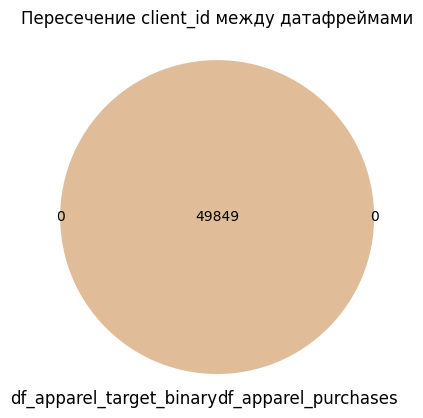

In [25]:
# отобразим пересечения визуально
set1 = set(df_apparel_target_binary['client_id'])
set2 = set(df_apparel_purchases['client_id'])

venn2([set1, set2], ('df_apparel_target_binary', 'df_apparel_purchases'))
plt.title('Пересечение client_id между датафреймами')
plt.show()

#### пересечения target и messages датафреймов

In [26]:
df_apparel_target_binary.shape[0], df_apparel_messages['client_id'].nunique()

(49849, 53329)

In [27]:
# series клиентов, которые совпадают
inters2 = pd.Series(
    list(
        set(df_apparel_target_binary['client_id']).intersection(
            set(df_apparel_messages['client_id'])
        )
    )
)

len(inters2)

41982

In [28]:
# сколько клиентов нет df_apparel_target_binary, их тех что есть в df_apparel_target_binary
print(f'{(1 - len(inters2) / df_apparel_target_binary.shape[0])*100:.2f}')

15.78


In [29]:
# сколько клиентов есть ещё в df_apparel_messages, которых нет в df_apparel_target_binary
print(f'{(1 - len(inters2) / df_apparel_messages["client_id"].nunique())*100:.2f}')

21.28


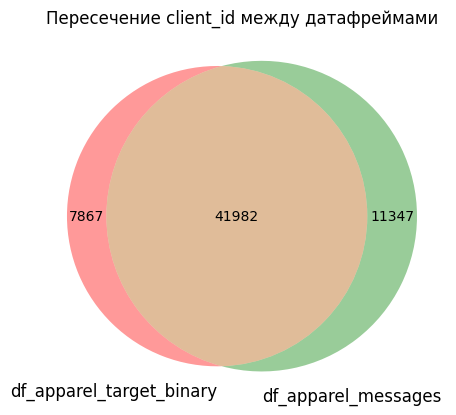

In [30]:
# отобразим пересечения визуально
set1 = set(df_apparel_target_binary['client_id'])
set2 = set(df_apparel_messages['client_id'])

venn2([set1, set2], ('df_apparel_target_binary', 'df_apparel_messages'))
plt.title('Пересечение client_id между датафреймами')
plt.show()

**Выводы**

 - `df_apparel_purchases` и `df_apparel_target_binary` - 100% пересечения, есть информация по всем пользователям.
 - `df_apparel_messages` и `df_apparel_target_binary` - ~84% пересечения, и есть дополнительные (21%) пользователи без таргета
 - В `df_apparel_messages` нет 15% пользователей из таргета, проверим совершали ли они покупку.

In [31]:
# классы клиентов, которые есть в target, но нет в messages (клиенты без данных о событиях)
rows = ~df_apparel_target_binary['client_id'].isin(inters2)

df_apparel_target_binary[rows]['target'].value_counts()

target
0    7752
1     115
Name: count, dtype: int64

В `df_apparel_messages` нет `115` пользователей которые совершили покупку, возможно это новые пользователи, или пользователи которые подписались на рассылку. Это большое кол-во данных относительно того, сколько мы вообще имеем пользователей данного класса. Удалять их не буду - это ценные данные, однако информации по сообщениям у них не будет.

## Заметки

 - Чем дальше от текущей даты поведенческие паттерны пользователя, тем меньшее влияение они будут оказывать на поведение в будущем. То есть данные за текущий год имеют больший вес чем данные за прошлый.

Следовательно:
 - Перевести данные из формата временных характеристик к формату частотных
 - Аггрегацию данных следует производить по срезам:
     - 30 дней за период [-30 дней; таргет]
     - 30 дней за период [-60 дней; -30 дней]
     - 30 дней за период [-90 дней; -60 дней]
     - 30 дней за период [-120 дней; -90 дней]
     - 30 дней за период [-180 дней; -120 дней]
 - Датафрейм при этом становится плоским: в одной строке будет содержаться вся необходимая информация об одном уникальном пользователе

In [32]:
df_apparel_messages.head()

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
0,4439,1515915625626736623,1515915625626736623-4439-6283415ac07ea,open,email,2022-05-19,2022-05-19 00:14:20
1,4439,1515915625490086521,1515915625490086521-4439-62834150016dd,open,email,2022-05-19,2022-05-19 00:39:34
2,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,open,email,2022-05-19,2022-05-19 00:51:49
3,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,click,email,2022-05-19,2022-05-19 00:52:20
4,4439,1515915625471518311,1515915625471518311-4439-628341570c133,open,email,2022-05-19,2022-05-19 00:56:52


## Разработка признаков

In [33]:
df_dev      = df_apparel_target_binary.copy()
df_dev_init = df_dev.copy()

print(f"Размерность изначального датафрейма: {df_dev_init.shape}")
print(f"Кол-во уникальных client_id        : {df_dev['client_id'].nunique()}")
print(f"Размерность текущего датафрейма    : {df_dev.shape}")

Размерность изначального датафрейма: (49849, 2)
Кол-во уникальных client_id        : 49849
Размерность текущего датафрейма    : (49849, 2)


In [34]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000


## Признаки из `df_apparel_purchases`

In [35]:
df_ap_dev = df_apparel_purchases.copy()
    
df_ap_dev.head()

,client_id,quantity,price,category_ids,date,message_id
0,1515915625468169594,1,1999.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1,1515915625468169594,1,2499.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
2,1515915625471138230,1,6499.0,"['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843
3,1515915625471138230,1,4999.0,"['4', '28', '244', '432']",2022-05-16,1515915625471138230-4437-6282242f27843
4,1515915625471138230,1,4999.0,"['4', '28', '49', '413']",2022-05-16,1515915625471138230-4437-6282242f27843


### Даты как признак

In [36]:
# Извлекаем год и месяц
df_ap_dev['year']       = df_ap_dev['date'].dt.year
df_ap_dev['month']      = df_ap_dev['date'].dt.month
df_ap_dev['month_year'] = df_ap_dev['date'].dt.to_period('M')

/tmp/ipykernel_15835/2083851264.py:14: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  monthly_counts = full_months.combine_first(monthly_counts).fillna(0)


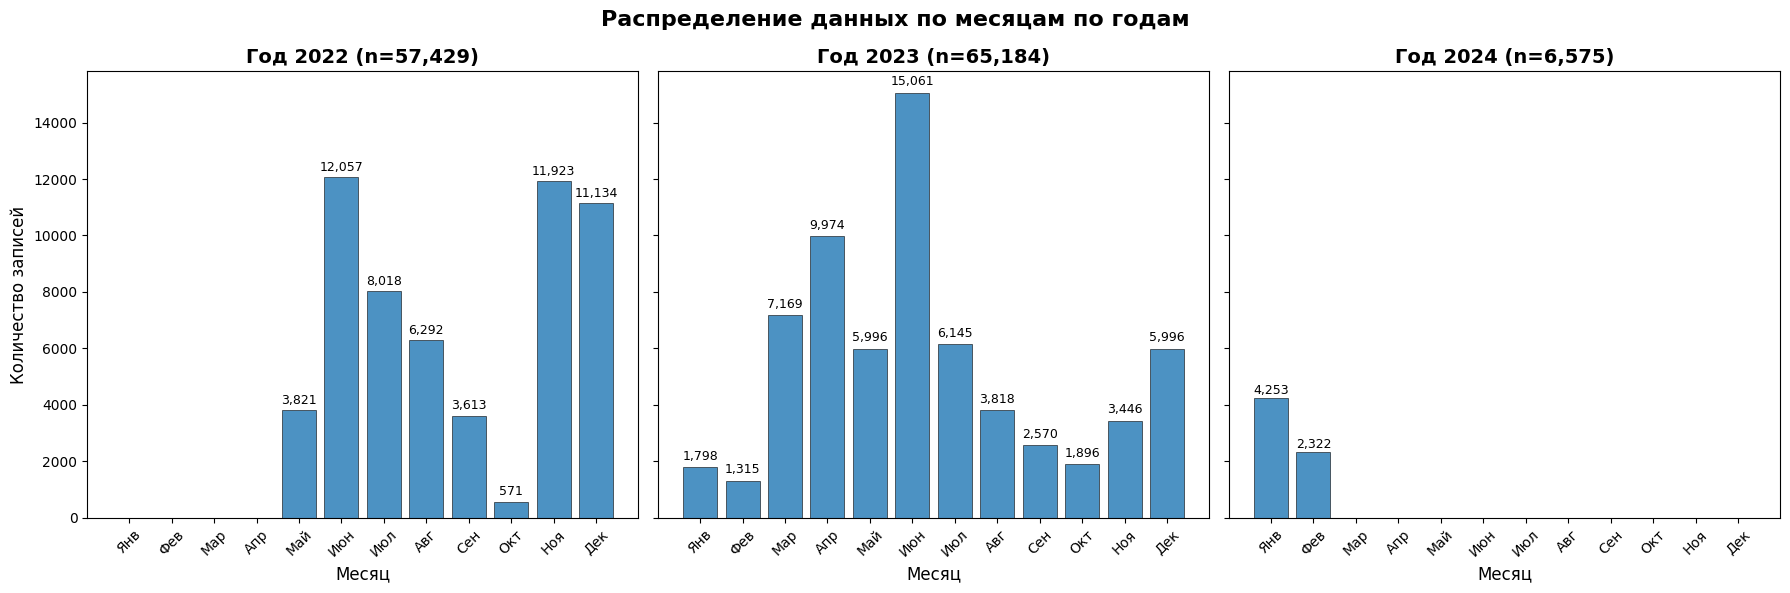

In [37]:
# графики распределения покупок по годам
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Распределение данных по месяцам по годам', fontsize=16, fontweight='bold')

years = [2022, 2023, 2024]

for idx, year in enumerate(years):
    ax        = axes[idx]
    year_data = df_ap_dev[df_ap_dev['year'] == year]
    
    monthly_counts = year_data.groupby('month').size()
    
    full_months    = pd.Series(index=range(1, 13), dtype='float64')
    monthly_counts = full_months.combine_first(monthly_counts).fillna(0)
    
    bars = ax.bar(
        range(1, 13),
        monthly_counts.values, 
        alpha=0.8,
        edgecolor='black',
        linewidth=0.5
    )
    
    ax.set_title(f'Год {year} (n={len(year_data):,})', fontsize=14, fontweight='bold')
    ax.set_xlabel('Месяц', fontsize=12)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(
        ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
         'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'],
        rotation=45
    )
    
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2.,
                height + max(monthly_counts)*0.01,
                f'{int(height):,}',
                ha='center',
                va='bottom',
                fontsize=9
            )

axes[0].set_ylabel('Количество записей', fontsize=12)
plt.tight_layout()
plt.show()

**Заметки**

 - Есть характерная сезонность, например пик покупок приходится на июнь
 - Модель должна уловить закономерность сезонного распределения

### Категории

In [38]:
# распределение уникальных категорий
df_ap_dev['category_ids'].value_counts()

category_ids
['4', '28', '57', '431']            6191
['4', '28', '244', '432']           4835
['4', '28', '260', '420']           4421
['4', '28', '275', '421']           3309
['2', '18', '258', '441']           3175
                                    ... 
['5562', '5589', '5624', '1696']       1
['4', '27', '350', '1589']             1
['5562', '5589', '5588', '1809']       1
['5562', '5597', '5642', '1218']       1
['4', '44', '1600']                    1
Name: count, Length: 933, dtype: int64

Всего 933 уникальных комбинации категорий с учетом вложенности

Рассмотрим категории подробнее

In [39]:
# преобразуем строки в списки
df_ap_dev['category_ids'] = df_ap_dev['category_ids'].apply(lambda x: ast.literal_eval(x))

In [40]:
df_ap_dev['cat_id_len'] = df_ap_dev['category_ids'].apply(lambda x: len(x))

df_ap_dev['cat_id_len'].value_counts(normalize=True)

cat_id_len
4    0.965624
0    0.021194
3    0.005697
1    0.004815
5    0.002671
Name: proportion, dtype: float64

96% категорий имеют размерность 4

In [41]:
# cмотрим категории с размерностью 0
rows = df_ap_dev['cat_id_len'] == 0

df_ap_dev[rows]['category_ids'].head(5)

22153    []
49215    []
53223    []
59056    []
60268    []
Name: category_ids, dtype: object

In [42]:
df_ap_dev[rows]['category_ids'].value_counts()

category_ids
[]    2738
Name: count, dtype: int64

In [43]:
# cмотрим категории с размерностью 1
rows = df_ap_dev['cat_id_len'] == 1

df_ap_dev[rows]['category_ids'].head(5)

14848    [None]
32281    [None]
32283    [None]
33447    [None]
33982    [None]
Name: category_ids, dtype: object

In [44]:
df_ap_dev[rows]['category_ids'].value_counts()

category_ids
[None]    622
Name: count, dtype: int64

In [45]:
# cмотрим категории с размерностью 3
rows = df_ap_dev['cat_id_len'] == 3

df_ap_dev[rows]['category_ids'].head(5)

55348     [4, 44, 428]
56942    [4, 44, 1594]
57592    [4, 44, 1594]
58626     [4, 44, 989]
59235     [4, 44, 489]
Name: category_ids, dtype: object

In [46]:
df_ap_dev[rows]['category_ids'].value_counts()

category_ids
[4, 44, 428]          125
[4, 44, 501]          101
[4, 44, 1594]          69
[4, 44, 491]           68
[4, 44, 1381]          61
[4, 44, 489]           55
[4, 44, 490]           52
[4, 44, 430]           47
[4, 44, 1097]          24
[4, 44, 549]           23
[4, 44, 493]           20
[4, 44, 1564]          16
[4, 29, 503]           14
[4, 44, 1571]          12
[4, 44, 989]           10
[5562, 5597, 5782]      9
[4, 44, 528]            8
[4, 44, 494]            7
[4, 44, 492]            6
[4, 1822, 499]          4
[4, 30, 503]            4
[4, 44, 1600]           1
Name: count, dtype: int64

In [47]:
# cмотрим категории с размерностью 4
rows = df_ap_dev['cat_id_len'] == 4

df_ap_dev[rows]['category_ids'].head(5)

0     [4, 28, 57, 431]
1     [4, 28, 57, 431]
2     [4, 28, 57, 431]
3    [4, 28, 244, 432]
4     [4, 28, 49, 413]
Name: category_ids, dtype: object

In [48]:
df_ap_dev[rows]['category_ids'].value_counts()

category_ids
[4, 28, 57, 431]            6191
[4, 28, 244, 432]           4835
[4, 28, 260, 420]           4421
[4, 28, 275, 421]           3309
[2, 18, 258, 441]           3175
                            ... 
[4, 28, 239, 6202]             1
[5562, 5597, 5642, 900]        1
[6060, 6057, 6243, 6264]       1
[6060, 6057, 6244, 6237]       1
[6060, 6057, 6244, 6236]       1
Name: count, Length: 908, dtype: int64

In [49]:
# cмотрим категории с размерностью 5
rows = df_ap_dev['cat_id_len'] == 5

df_ap_dev[rows]['category_ids'].head(5)

1703    [2, 17, 330, 387, 467]
1727    [2, 17, 330, 387, 467]
2093    [2, 17, 330, 387, 467]
2794    [2, 17, 330, 387, 467]
4827    [2, 17, 330, 387, 467]
Name: category_ids, dtype: object

In [50]:
df_ap_dev[rows]['category_ids'].value_counts()

category_ids
[2, 17, 330, 387, 467]    345
Name: count, dtype: int64

933 категории, среди которых:
 - 0 размерность - пустые (2% данных) // охватывают 1 категорию
 - 1 размерность - пустые менее 1% данных // охватывают 1 категорию
 - 3 размерность - менее 1% данных // охватывают 22 категрии
 - 4 размерность - самые распространенные (124_000 записей / 96%) // охватывают 908 категорий, расмотрим подробнее
 - 5 размерность - менее 1% // охватывают 1 категорию

### Добавим признаки по уровням категории (в первую очередь для анализа)

Размерность всех категорий нужно привести к единому виду, берем максимальный размер = 5

Пустые категории заполним нулями [0,0,0,0,0]

In [51]:
# заполним нулями пустые категории []
rows = df_ap_dev['cat_id_len'] == 0

df_ap_dev.loc[rows, 'category_ids'] = "[0, 0, 0, 0, 0]"
df_ap_dev.loc[rows, 'category_ids'] = df_ap_dev.loc[rows, 'category_ids'].apply(lambda x: ast.literal_eval(x))

In [52]:
# заполним нулями пустые категории (nan)
rows = df_ap_dev['cat_id_len'] == 1

df_ap_dev.loc[rows, 'category_ids'] = "[0, 0, 0, 0, 0]"
df_ap_dev.loc[rows, 'category_ids'] = df_ap_dev.loc[rows, 'category_ids'].apply(lambda x: ast.literal_eval(x))

In [53]:
# приведем категорию с размерностью 3 к размерности 5
rows = df_ap_dev['cat_id_len'] == 3

df_ap_dev.loc[rows, 'category_ids'] = df_ap_dev.loc[rows, 'category_ids'].apply(lambda x: x + ["0", "0"])

df_ap_dev.loc[rows, 'category_ids'].head(5)

55348     [4, 44, 428, 0, 0]
56942    [4, 44, 1594, 0, 0]
57592    [4, 44, 1594, 0, 0]
58626     [4, 44, 989, 0, 0]
59235     [4, 44, 489, 0, 0]
Name: category_ids, dtype: object

In [54]:
# приведем категорию с размерностью 4 к размерности 5
rows = df_ap_dev['cat_id_len'] == 4

df_ap_dev.loc[rows, 'category_ids'] = df_ap_dev.loc[rows, 'category_ids'].apply(lambda x: x + ["0"])

df_ap_dev.loc[rows, 'category_ids'].head(5)

0     [4, 28, 57, 431, 0]
1     [4, 28, 57, 431, 0]
2     [4, 28, 57, 431, 0]
3    [4, 28, 244, 432, 0]
4     [4, 28, 49, 413, 0]
Name: category_ids, dtype: object

In [55]:
# проверим размерность всех категорий, должна быть 5
df_ap_dev['cat_id_len_norm'] = df_ap_dev['category_ids'].apply(lambda x: len(x))

df_ap_dev['cat_id_len_norm'].value_counts()

cat_id_len_norm
5    129188
Name: count, dtype: int64

In [56]:
# создаем признаки по уровням категорий

def create_features_from_cats(df: pd.DataFrame) -> pd.DataFrame:

    for lvl in [1, 2, 3, 4, 5]:
        df[f'_cat_ld_lvl_{lvl}'] = df['category_ids'].apply(lambda x: x[lvl-1])

    return df

df_ap_dev = create_features_from_cats(df_ap_dev)

df_ap_dev.head(5)

,client_id,quantity,price,category_ids,date,message_id,year,month,month_year,cat_id_len,cat_id_len_norm,_cat_ld_lvl_1,_cat_ld_lvl_2,_cat_ld_lvl_3,_cat_ld_lvl_4,_cat_ld_lvl_5
0,1515915625468169594,1,1999.0,"[4, 28, 57, 431, 0]",2022-05-16,1515915625468169594-4301-627b661e9736d,2022,5,2022-05,4,5,4,28,57,431,0
1,1515915625468169594,1,2499.0,"[4, 28, 57, 431, 0]",2022-05-16,1515915625468169594-4301-627b661e9736d,2022,5,2022-05,4,5,4,28,57,431,0
2,1515915625471138230,1,6499.0,"[4, 28, 57, 431, 0]",2022-05-16,1515915625471138230-4437-6282242f27843,2022,5,2022-05,4,5,4,28,57,431,0
3,1515915625471138230,1,4999.0,"[4, 28, 244, 432, 0]",2022-05-16,1515915625471138230-4437-6282242f27843,2022,5,2022-05,4,5,4,28,244,432,0
4,1515915625471138230,1,4999.0,"[4, 28, 49, 413, 0]",2022-05-16,1515915625471138230-4437-6282242f27843,2022,5,2022-05,4,5,4,28,49,413,0


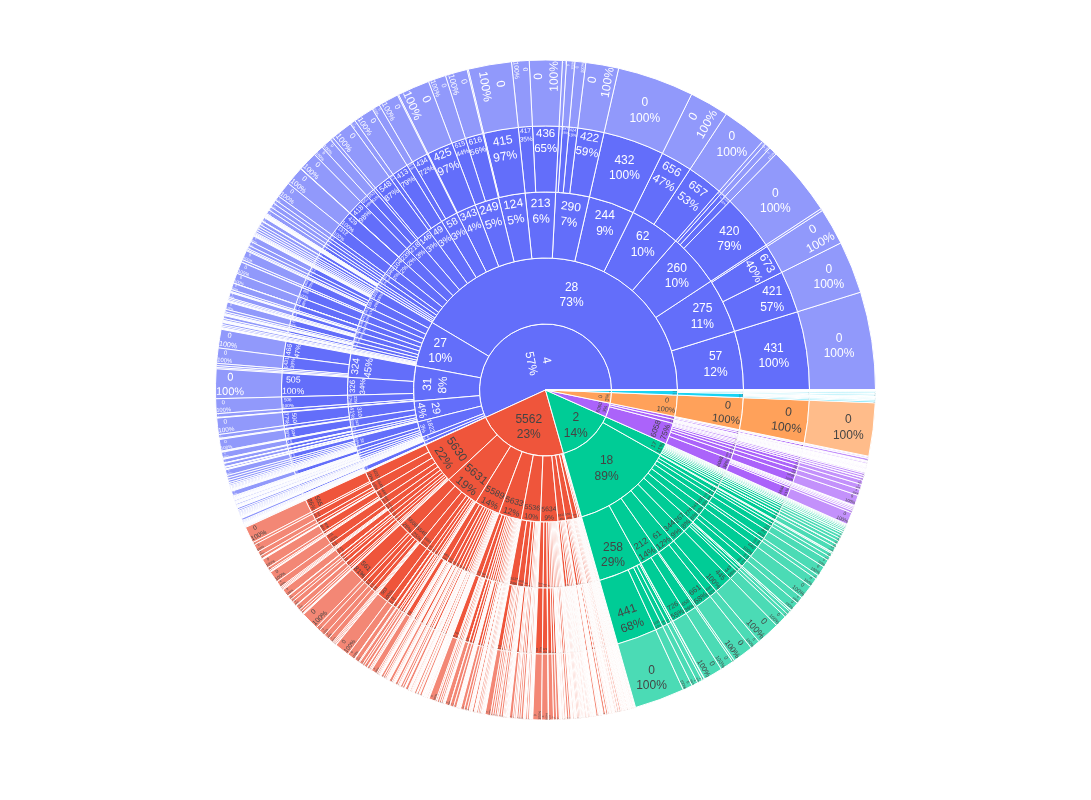

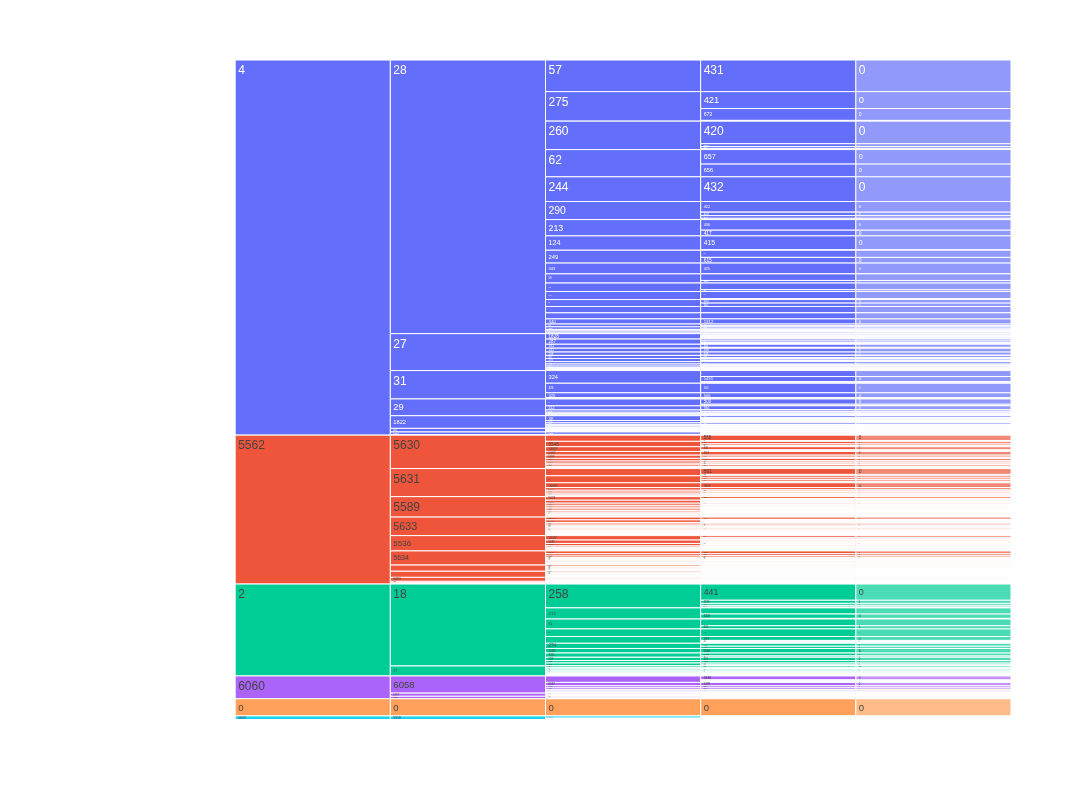

In [57]:
# Создаем структуру данных для sunburst или icicle chart
df_hierarchy = df_ap_dev.copy()

# Sunburst диаграмма (интерактивная)
fig = px.sunburst(
    df_hierarchy,
    path=['_cat_ld_lvl_1', '_cat_ld_lvl_2', '_cat_ld_lvl_3', 
          '_cat_ld_lvl_4', '_cat_ld_lvl_5'],
    maxdepth=5,
    width=1000,
    height=800
)
fig.update_traces(textinfo="label+percent parent")
fig.show()

# Или Icicle диаграмма
fig = px.icicle(
    df_hierarchy,
    path=['_cat_ld_lvl_1', '_cat_ld_lvl_2', '_cat_ld_lvl_3', 
          '_cat_ld_lvl_4', '_cat_ld_lvl_5'],
    width=1000,
    height=800
)
fig.show()

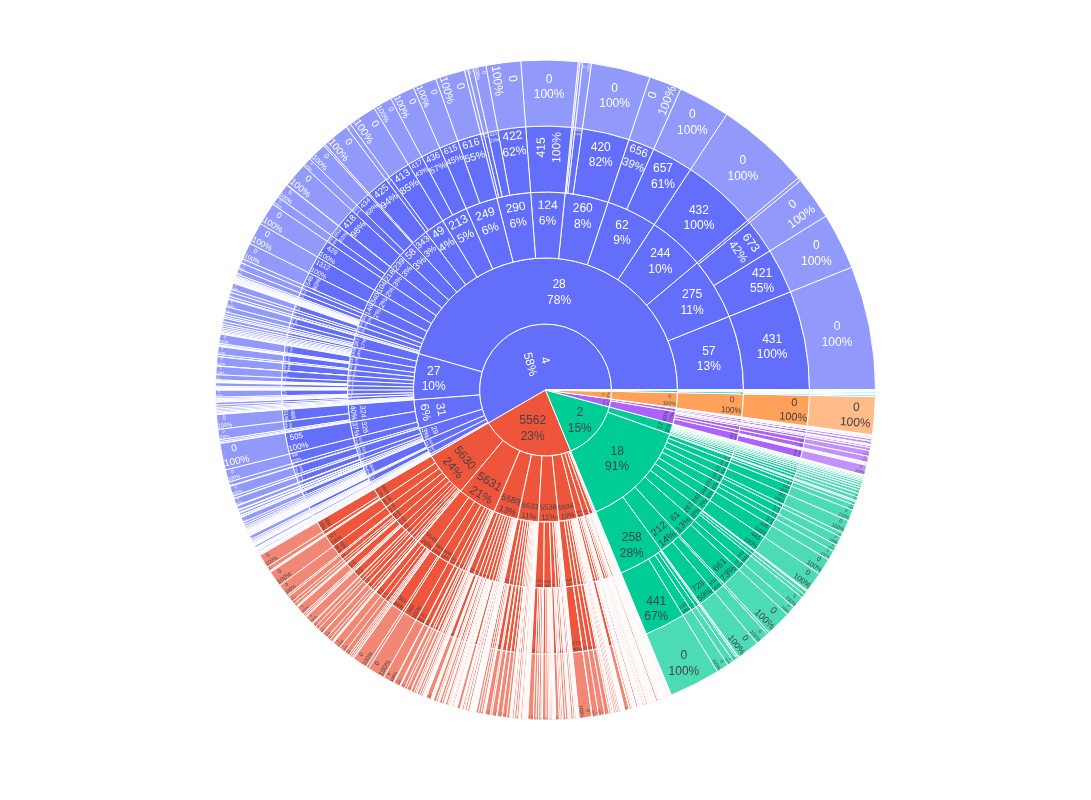

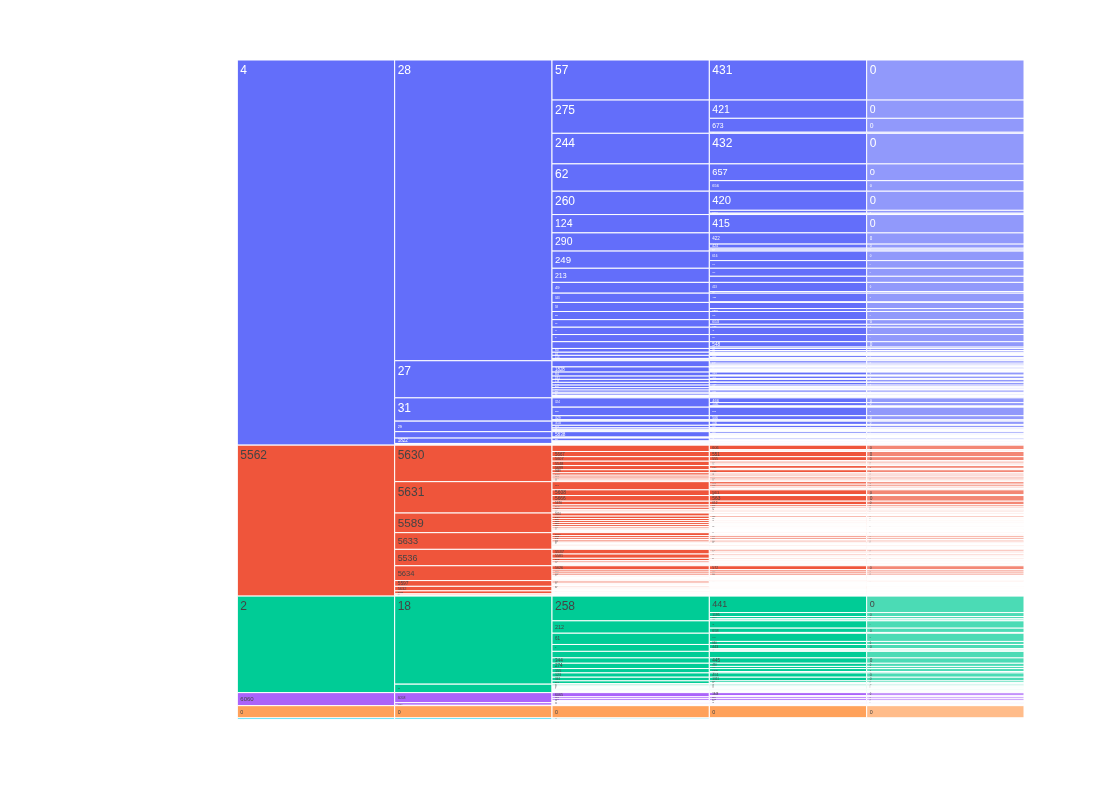

In [58]:
# за 2022 год
# Создаем структуру данных для sunburst или icicle chart
rows         = df_ap_dev['year'] == 2022
df_hierarchy = df_ap_dev[rows].copy()

# Sunburst диаграмма (интерактивная)
fig = px.sunburst(
    df_hierarchy,
    path=['_cat_ld_lvl_1', '_cat_ld_lvl_2', '_cat_ld_lvl_3', 
          '_cat_ld_lvl_4', '_cat_ld_lvl_5'],
    maxdepth=5,
    width=1000,
    height=800
)
fig.update_traces(textinfo="label+percent parent")
fig.show()

# Или Icicle диаграмма
fig = px.icicle(
    df_hierarchy,
    path=['_cat_ld_lvl_1', '_cat_ld_lvl_2', '_cat_ld_lvl_3', 
          '_cat_ld_lvl_4', '_cat_ld_lvl_5'],
    width=1000,
    height=800
)
fig.show()

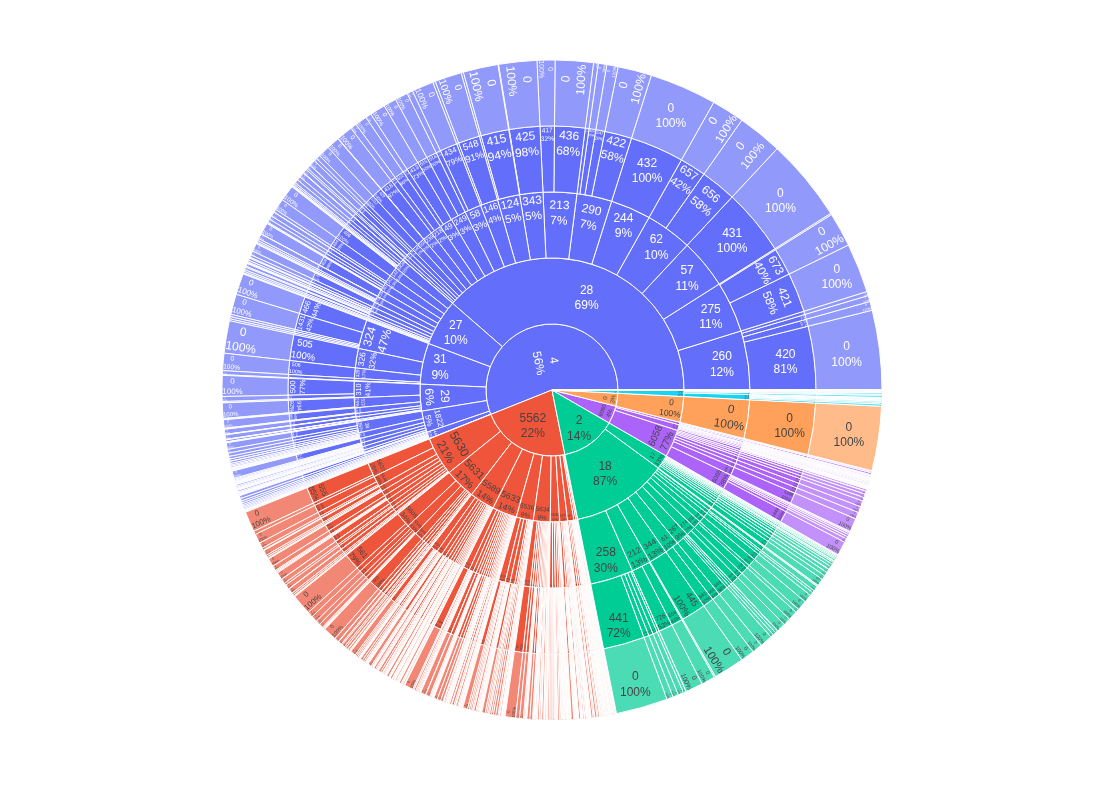

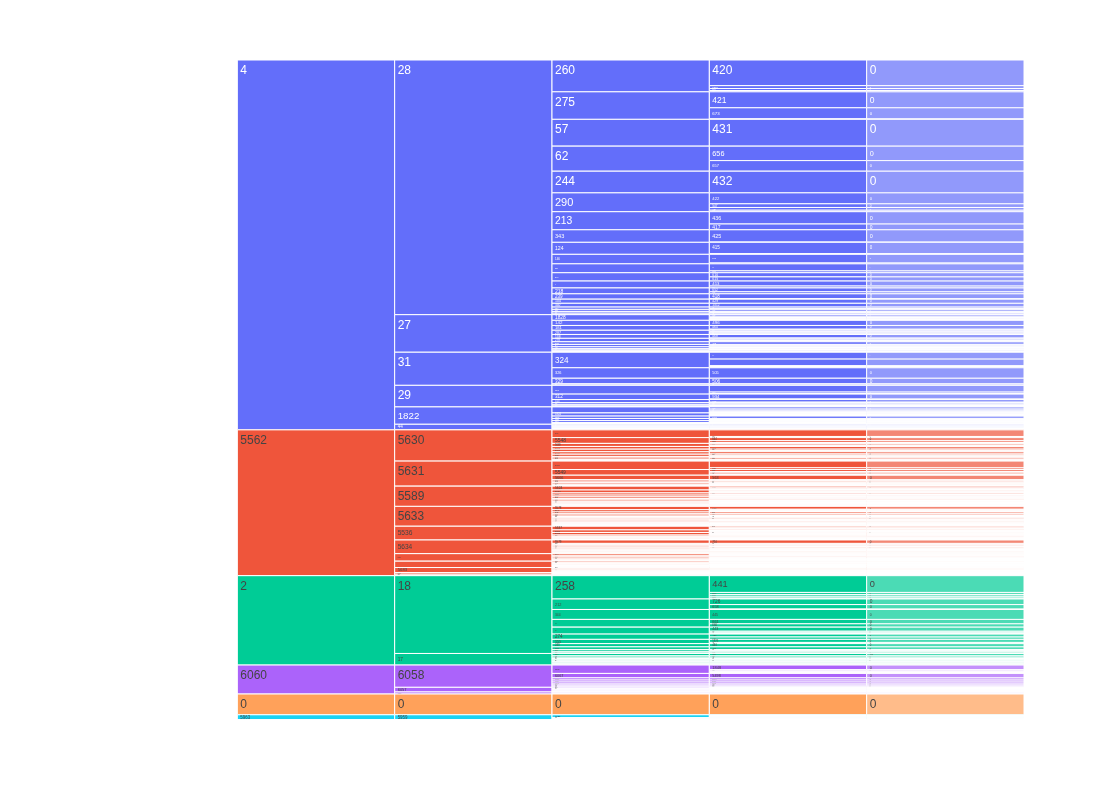

In [59]:
# за 2023 год
# Создаем структуру данных для sunburst или icicle chart
rows         = df_ap_dev['year'] == 2023
df_hierarchy = df_ap_dev[rows].copy()

# Sunburst диаграмма (интерактивная)
fig = px.sunburst(
    df_hierarchy,
    path=['_cat_ld_lvl_1', '_cat_ld_lvl_2', '_cat_ld_lvl_3', 
          '_cat_ld_lvl_4', '_cat_ld_lvl_5'],
    maxdepth=5,
    width=1000,
    height=800
)
fig.update_traces(textinfo="label+percent parent")
fig.show()

# Или Icicle диаграмма
fig = px.icicle(
    df_hierarchy,
    path=['_cat_ld_lvl_1', '_cat_ld_lvl_2', '_cat_ld_lvl_3', 
          '_cat_ld_lvl_4', '_cat_ld_lvl_5'],
    width=1000,
    height=800
)
fig.show()

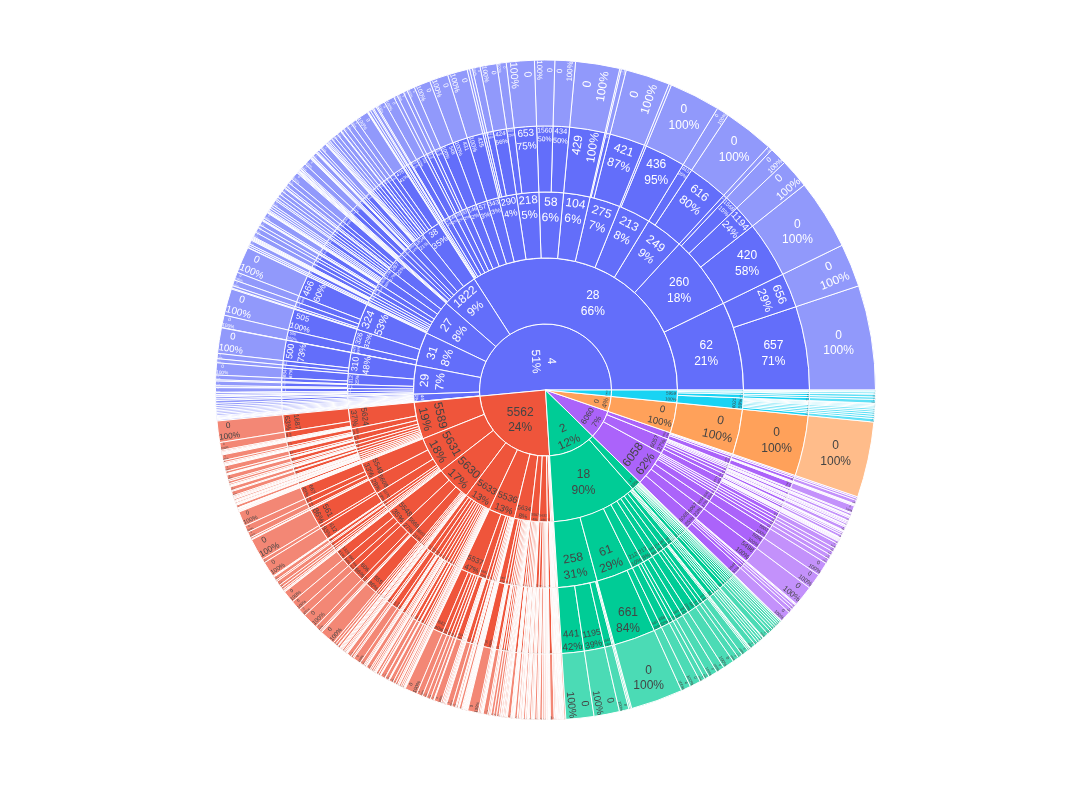

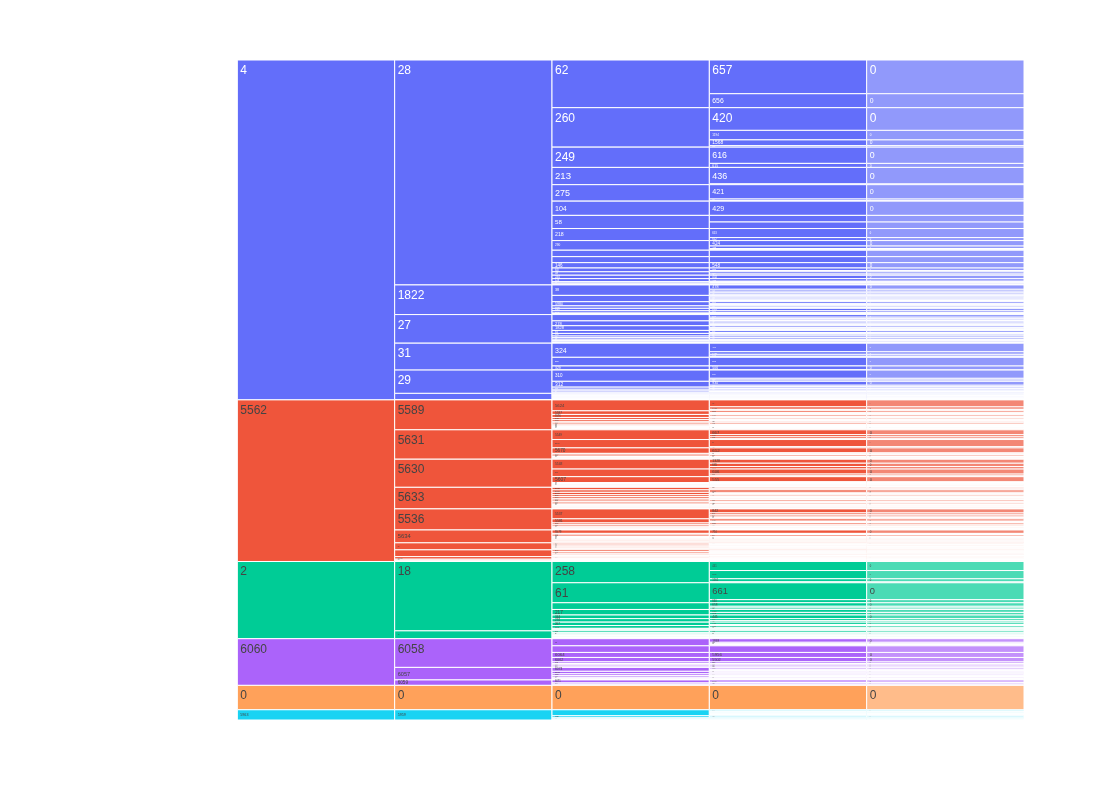

In [60]:
# за 2024 год
# Создаем структуру данных для sunburst или icicle chart
rows         = df_ap_dev['year'] == 2024
df_hierarchy = df_ap_dev[rows].copy()

# Sunburst диаграмма (интерактивная)
fig = px.sunburst(
    df_hierarchy,
    path=['_cat_ld_lvl_1', '_cat_ld_lvl_2', '_cat_ld_lvl_3', 
          '_cat_ld_lvl_4', '_cat_ld_lvl_5'],
    maxdepth=5,
    width=1000,
    height=800
)
fig.update_traces(textinfo="label+percent parent")
fig.show()

# Или Icicle диаграмма
fig = px.icicle(
    df_hierarchy,
    path=['_cat_ld_lvl_1', '_cat_ld_lvl_2', '_cat_ld_lvl_3', 
          '_cat_ld_lvl_4', '_cat_ld_lvl_5'],
    width=1000,
    height=800
)
fig.show()

**Заметки**

Кластеры сохраняют размеры от года к году

Задача - снизить размерность с 933 до рационального значения.
Рациональным в данном случае будет вариант разделения данных на кластеры. Из диаграммы визуально можно выделить следующие мажорные кластеры:
 - [4, 28] -> cat_1
 - [4, остальное] -> cat_2
 - [5562] -> cat_3
 - [2] -> cat_4
 - [6060] -> cat_5
 - [0] -> cat_6
 - [остальное] -> cat_7

In [61]:
rows = (df_ap_dev['_cat_ld_lvl_1'] == "4") & (df_ap_dev['_cat_ld_lvl_2'] == "28")

df_ap_dev.loc[rows, "simple_cat"] = "cat_1"

In [62]:
rows = (df_ap_dev['_cat_ld_lvl_1'] == "4") & (df_ap_dev['_cat_ld_lvl_2'] != "28")

df_ap_dev.loc[rows, "simple_cat"] = "cat_2"

In [63]:
rows = (df_ap_dev['_cat_ld_lvl_1'] == "5562")

df_ap_dev.loc[rows, "simple_cat"] = "cat_3"

In [64]:
rows = (df_ap_dev['_cat_ld_lvl_1'] == "2")

df_ap_dev.loc[rows, "simple_cat"] = "cat_4"

In [65]:
rows = (df_ap_dev['_cat_ld_lvl_1'] == "6060")

df_ap_dev.loc[rows, "simple_cat"] = "cat_5"

In [66]:
rows = (df_ap_dev['_cat_ld_lvl_1'] == 0)

df_ap_dev.loc[rows, "simple_cat"] = "cat_6"

In [67]:
rows = (df_ap_dev['_cat_ld_lvl_1'] != "4") &\
    (df_ap_dev['_cat_ld_lvl_1'] != "5562") &\
    (df_ap_dev['_cat_ld_lvl_1'] != "2") &\
    (df_ap_dev['_cat_ld_lvl_1'] != "6060") &\
    (df_ap_dev['_cat_ld_lvl_1'] != 0)

df_ap_dev.loc[rows, "simple_cat"] = "cat_7"

In [68]:
df_ap_dev["simple_cat"].value_counts()

simple_cat
cat_1    53564
cat_3    29148
cat_2    19864
cat_4    17995
cat_5     4458
cat_6     3360
cat_7      799
Name: count, dtype: int64

In [69]:
display_missing(df_ap_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
quantity,0,0.000000
price,0,0.000000
category_ids,0,0.000000
date,0,0.000000
message_id,0,0.000000
year,0,0.000000
month,0,0.000000
month_year,0,0.000000
cat_id_len,0,0.000000


In [70]:
def get_mode_from_simple_cat(series):

    temp_storage = []
    
    try:
        for s in series:
            temp_storage.append(s) 

        return statistics.mode(temp_storage)

    except Exception as e:
        print(f"Error : {len(series)} : {e}")

In [71]:
df_temp_simple_cat = df_ap_dev.groupby("client_id")["simple_cat"].apply(get_mode_from_simple_cat)

df_temp_simple_cat.shape

(49849,)

In [72]:
df_temp_simple_cat

client_id
1515915625468060902    cat_1
1515915625468061003    cat_1
1515915625468061099    cat_1
1515915625468061100    cat_2
1515915625468061170    cat_1
                       ...  
1515915626010261344    cat_4
1515915626010266132    cat_2
1515915626010439406    cat_2
1515915626010443527    cat_4
1515915626010443624    cat_1
Name: simple_cat, Length: 49849, dtype: object

In [73]:
df_dev.shape

(49849, 2)

In [74]:
df_dev = df_dev.merge(df_temp_simple_cat, on='client_id', how='left')

In [75]:
print(f"Размерность изначального датафрейма: {df_dev_init.shape}")
print(f"Размерность текущего датафрейма    : {df_dev.shape}")
print(f"Кол-во уникальных client_id        : {df_dev['client_id'].nunique()}")

Размерность изначального датафрейма: (49849, 2)
Размерность текущего датафрейма    : (49849, 3)
Кол-во уникальных client_id        : 49849


In [76]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
simple_cat,0,0.000000


In [77]:
df_apparel_purchases['category_ids'] = df_apparel_purchases['category_ids'].apply(lambda x: ast.literal_eval(x))

In [78]:
def get_mode_from_last(series):
    
    temp_storage = []
    
    try:
        if len(series) > 3:
            for s in series:
                if len(s) > 0:
                    temp_storage.append(s[-1]) 
                else:
                    pass
        else:
            return 0

        if len(temp_storage) > 0:
            return statistics.mode(temp_storage)
        else:
            return 0
        
    except Exception as e:
        print(f"Error : {len(series)} : {e}")

In [79]:
df_temp = df_apparel_purchases.groupby('client_id')['category_ids'].apply(get_mode_from_last)

df_temp = df_temp.reset_index().rename(columns={'category_ids': 'cat.mode.last'})

df_dev  = df_dev.merge(df_temp, on='client_id', how='left')

In [80]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
simple_cat,0,0.000000
cat.mode.last,31,0.060000


In [82]:
df_dev = df_dev.fillna(0)

In [83]:
df_dev['cat.mode.last'].value_counts()

cat.mode.last
0       40033
431       546
432       385
420       320
421       255
        ...  
6091        1
1288        1
1078        1
5786        1
5781        1
Name: count, Length: 556, dtype: int64

## Признаки из `df_apparel_message`

In [84]:
df_apparel_messages.columns.to_list()

['bulk_campaign_id',
 'client_id',
 'message_id',
 'event',
 'channel',
 'date',
 'created_at']

### События (event)

In [85]:
df_apparel_messages['event'].value_counts()

event
send           9058174
open           3052481
click           483326
purchase         62593
hard_bounce      19763
soft_bounce      10582
unsubscribe       2833
hbq_spam           823
complain           527
subscribe           85
close                1
Name: count, dtype: int64

In [86]:
# функция которая создаст признаки по годам и типу события
def create_event_features_by_period(df: pd.DataFrame, depth: int, event: str) -> pd.DataFrame:
    """
    Формирует кол-во событий типа event как значение признака.
    Признаки формируются за период в 30 дней с глубиной depth.
    """
    rows = ((df['date'].max() - pd.Timedelta(days=(depth - 120))) > df['date']) &\
        (df['date'] >= (df['date'].max() - pd.Timedelta(days=depth))) &\
        (df['event'] == event)

    temp_df = df[rows].groupby('client_id').agg({
        'event': ['count']
    })

    temp_df.columns = [f'ev.d{depth}_{depth - 120}.{event}.c']

    return temp_df.reset_index()

In [87]:
# добавляем признаки по годам на основе события "purchase"
for period in [120, 240, 360, 480, 600]:

    df_dev = df_dev.merge(create_event_features_by_period(df_apparel_messages, period, "purchase"), on='client_id', how='left')

In [88]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
simple_cat,0,0.000000
cat.mode.last,0,0.000000
ev.d120_0.purchase.c,44727,89.720000
ev.d240_120.purchase.c,44886,90.040000
ev.d360_240.purchase.c,40976,82.200000
ev.d480_360.purchase.c,42828,85.920000
ev.d600_480.purchase.c,40078,80.400000


In [89]:
# заполняем нулями записи для пользователей, у которых событий данного типа не было в указанный период
df_dev = df_dev.fillna(0)

In [90]:
# добавляем признаки по годам на основе события "open"
for period in [120, 240, 360, 480, 600]:

    df_dev = df_dev.merge(create_event_features_by_period(df_apparel_messages, period, "open"), on='client_id', how='left')

In [91]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
simple_cat,0,0.000000
cat.mode.last,0,0.000000
ev.d120_0.purchase.c,0,0.000000
ev.d240_120.purchase.c,0,0.000000
ev.d360_240.purchase.c,0,0.000000
ev.d480_360.purchase.c,0,0.000000
ev.d600_480.purchase.c,0,0.000000
ev.d120_0.open.c,25028,50.210000


In [92]:
df_dev = df_dev.fillna(0)

In [93]:
# добавляем признаки по годам на основе события "click"
for period in [120, 240, 360, 480, 600]:

    df_dev = df_dev.merge(create_event_features_by_period(df_apparel_messages, period, "click"), on='client_id', how='left')

In [94]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
simple_cat,0,0.000000
cat.mode.last,0,0.000000
ev.d120_0.purchase.c,0,0.000000
ev.d240_120.purchase.c,0,0.000000
ev.d360_240.purchase.c,0,0.000000
ev.d480_360.purchase.c,0,0.000000
ev.d600_480.purchase.c,0,0.000000
ev.d120_0.open.c,0,0.000000


In [95]:
df_dev = df_dev.fillna(0)

In [96]:
# добавляем признаки по годам на основе события "send"
for period in [120, 240, 360, 480, 600]:

    df_dev = df_dev.merge(create_event_features_by_period(df_apparel_messages, period, "send"), on='client_id', how='left')

In [97]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
simple_cat,0,0.000000
cat.mode.last,0,0.000000
ev.d120_0.purchase.c,0,0.000000
ev.d240_120.purchase.c,0,0.000000
ev.d360_240.purchase.c,0,0.000000
ev.d480_360.purchase.c,0,0.000000
ev.d600_480.purchase.c,0,0.000000
ev.d120_0.open.c,0,0.000000


In [98]:
df_dev = df_dev.fillna(0)

In [99]:
# для событий типа "unsubsribe" периодичность не имеет значения, создадим признак за всю историю сообщений
rows = df_apparel_messages["event"] == "unsubscribe"

temp_df = df_apparel_messages[rows].groupby("client_id").agg({
        'event': ['count']
})

temp_df.columns = ["ev.unsubscribe.c"]

temp_df["ev.unsubscribe.c"].value_counts()

ev.unsubscribe.c
1    1741
2     372
3      65
4      17
5       6
6       4
8       3
7       1
Name: count, dtype: int64

In [100]:
df_dev = df_dev.merge(temp_df.reset_index(), on='client_id', how='left')

In [101]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
simple_cat,0,0.000000
cat.mode.last,0,0.000000
ev.d120_0.purchase.c,0,0.000000
ev.d240_120.purchase.c,0,0.000000
ev.d360_240.purchase.c,0,0.000000
ev.d480_360.purchase.c,0,0.000000
ev.d600_480.purchase.c,0,0.000000
ev.d120_0.open.c,0,0.000000


In [102]:
df_dev = df_dev.fillna(0)

In [103]:
# для событий типа "hard_bounce" + "soft_bounce" периодичность не имеет значения, создадим признак за всю историю сообщений
rows = (df_apparel_messages["event"] == "hard_bounce") | (df_apparel_messages["event"] == "soft_bounce")

temp_df = df_apparel_messages[rows].groupby("client_id").agg({
        'event': ['count']
})

temp_df.columns = ["ev.h_s_bounce.c"]

temp_df["ev.h_s_bounce.c"].value_counts()

ev.h_s_bounce.c
1      9613
2      2485
3       812
4       342
5       190
       ... 
134       1
63        1
38        1
115       1
52        1
Name: count, Length: 81, dtype: int64

In [104]:
df_dev = df_dev.merge(temp_df.reset_index(), on='client_id', how='left')

In [105]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
simple_cat,0,0.000000
cat.mode.last,0,0.000000
ev.d120_0.purchase.c,0,0.000000
ev.d240_120.purchase.c,0,0.000000
ev.d360_240.purchase.c,0,0.000000
ev.d480_360.purchase.c,0,0.000000
ev.d600_480.purchase.c,0,0.000000
ev.d120_0.open.c,0,0.000000


In [106]:
df_dev = df_dev.fillna(0)

### Каналы (channels)

In [107]:
# добавляем признак канала, через который пришло уведомление, и покупка была оплачена
rows = (df_apparel_messages["channel"] == "email") & (df_apparel_messages["event"] == "purchase") 

temp_df = df_apparel_messages[rows].groupby("client_id").agg({
        'event': ['count']
})

temp_df.columns = ["ch.email.purch.c"]

temp_df["ch.email.purch.c"].value_counts()

ch.email.purch.c
1      21061
2       4985
3       1611
4        709
5        378
6        192
7         80
8         54
9         37
11        14
10        14
13        11
14         8
12         7
15         4
16         3
17         2
22         1
20         1
81         1
26         1
117        1
36         1
19         1
23         1
29         1
Name: count, dtype: int64

In [108]:
df_dev = df_dev.merge(temp_df.reset_index(), on='client_id', how='left')

In [109]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
simple_cat,0,0.000000
cat.mode.last,0,0.000000
ev.d120_0.purchase.c,0,0.000000
ev.d240_120.purchase.c,0,0.000000
ev.d360_240.purchase.c,0,0.000000
ev.d480_360.purchase.c,0,0.000000
ev.d600_480.purchase.c,0,0.000000
ev.d120_0.open.c,0,0.000000


In [110]:
# добавляем признак канала, через который пришло уведомление, и покупка была оплачена
rows = (df_apparel_messages["channel"] == "mobile_push") & (df_apparel_messages["event"] == "purchase") 

temp_df = df_apparel_messages[rows].groupby("client_id").agg({
        'event': ['count']
})

temp_df.columns = ["ch.push.purch.c"]

temp_df["ch.push.purch.c"].value_counts()

ch.push.purch.c
1     10208
2      1800
3       576
4       210
5       119
6        60
7        31
8        15
9        13
10       12
11        6
16        5
14        3
12        3
17        2
25        2
15        2
18        1
75        1
23        1
19        1
Name: count, dtype: int64

In [111]:
df_dev = df_dev.merge(temp_df.reset_index(), on='client_id', how='left')

In [112]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
simple_cat,0,0.000000
cat.mode.last,0,0.000000
ev.d120_0.purchase.c,0,0.000000
ev.d240_120.purchase.c,0,0.000000
ev.d360_240.purchase.c,0,0.000000
ev.d480_360.purchase.c,0,0.000000
ev.d600_480.purchase.c,0,0.000000
ev.d120_0.open.c,0,0.000000


In [113]:
df_dev = df_dev.fillna(0)

In [114]:
print(f"Размерность изначального датафрейма: {df_dev_init.shape}")
print(f"Размерность текущего датафрейма    : {df_dev.shape}")
print(f"Кол-во уникальных client_id        : {df_dev['client_id'].nunique()}")

Размерность изначального датафрейма: (49849, 2)
Размерность текущего датафрейма    : (49849, 28)
Кол-во уникальных client_id        : 49849


### Кампании (bulk_campaign_id)

In [115]:
# сколько кампаний было у каждого пользователя
temp_df = df_apparel_messages.groupby("client_id")['bulk_campaign_id'].nunique()

In [116]:
temp_df.reset_index()

,client_id,bulk_campaign_id
0,1515915625468060902,127
1,1515915625468061003,154
2,1515915625468061099,215
3,1515915625468061100,265
4,1515915625468061170,240
...,...,...
53324,1515915626010183608,2
53325,1515915626010221592,2
53326,1515915626010234726,1
53327,1515915626010261344,1


In [117]:
df_dev = df_dev.merge(temp_df.reset_index(), on='client_id', how='left')

In [118]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
simple_cat,0,0.000000
cat.mode.last,0,0.000000
ev.d120_0.purchase.c,0,0.000000
ev.d240_120.purchase.c,0,0.000000
ev.d360_240.purchase.c,0,0.000000
ev.d480_360.purchase.c,0,0.000000
ev.d600_480.purchase.c,0,0.000000
ev.d120_0.open.c,0,0.000000


In [119]:
df_dev = df_dev.fillna(0)

In [120]:
print(f"Размерность изначального датафрейма: {df_dev_init.shape}")
print(f"Размерность текущего датафрейма    : {df_dev.shape}")
print(f"Кол-во уникальных client_id        : {df_dev['client_id'].nunique()}")

Размерность изначального датафрейма: (49849, 2)
Размерность текущего датафрейма    : (49849, 29)
Кол-во уникальных client_id        : 49849


## Признаки из `df_apparel_purchases`

In [121]:
df_apparel_purchases.head()

,client_id,quantity,price,category_ids,date,message_id
0,1515915625468169594,1,1999.0,"[4, 28, 57, 431]",2022-05-16,1515915625468169594-4301-627b661e9736d
1,1515915625468169594,1,2499.0,"[4, 28, 57, 431]",2022-05-16,1515915625468169594-4301-627b661e9736d
2,1515915625471138230,1,6499.0,"[4, 28, 57, 431]",2022-05-16,1515915625471138230-4437-6282242f27843
3,1515915625471138230,1,4999.0,"[4, 28, 244, 432]",2022-05-16,1515915625471138230-4437-6282242f27843
4,1515915625471138230,1,4999.0,"[4, 28, 49, 413]",2022-05-16,1515915625471138230-4437-6282242f27843


### Кол-по покупок за период quantity и price

In [122]:
# функция которая создаст признаки по годам
def create_qty_price_features_by_period(df: pd.DataFrame, depth: int) -> pd.DataFrame:
    """
    Формирует кол-во событий типа event как значение признака.
    Признаки формируются за период в 90 дней с глубиной depth.
    """
    rows = ((df['date'].max() - pd.Timedelta(days=(depth - 120))) > df['date']) &\
        (df['date'] >= (df['date'].max() - pd.Timedelta(days=depth)))

    temp_df = df[rows].groupby('client_id').agg({
        'quantity': ['sum'],
        'price': ['sum']
    })

    temp_df.columns = [f'qty.d{depth}_{depth - 120}.s', f'price.d{depth}_{depth - 120}.s']

    return temp_df.reset_index()

In [123]:
# добавляем признаки по годам на основе события "click"
for period in [120, 240, 360, 480, 600]:

    df_dev = df_dev.merge(create_qty_price_features_by_period(df_apparel_purchases, period), on='client_id', how='left')

In [124]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
simple_cat,0,0.000000
cat.mode.last,0,0.000000
ev.d120_0.purchase.c,0,0.000000
ev.d240_120.purchase.c,0,0.000000
ev.d360_240.purchase.c,0,0.000000
ev.d480_360.purchase.c,0,0.000000
ev.d600_480.purchase.c,0,0.000000
ev.d120_0.open.c,0,0.000000


In [125]:
df_dev = df_dev.fillna(0)

In [126]:
# добавляем признаки сумарного кол-ва покупок и стоимости за всё время
temp_df = df_apparel_purchases.groupby("client_id").agg({
        'price': ['sum'],
        'quantity': ['sum']
})

temp_df.columns = ["price.s", "qty.s"]

temp_df.value_counts()

price.s  qty.s
999.0    1        1968
1999.0   1        1796
1499.0   1        1648
699.0    1         831
2499.0   1         813
                  ... 
2902.0   11          1
2904.0   3           1
2906.0   3           1
         10          1
2897.0   4           1
Name: count, Length: 13099, dtype: int64

In [127]:
df_dev = df_dev.merge(temp_df.reset_index(), on='client_id', how='left')

In [128]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
simple_cat,0,0.000000
cat.mode.last,0,0.000000
ev.d120_0.purchase.c,0,0.000000
ev.d240_120.purchase.c,0,0.000000
ev.d360_240.purchase.c,0,0.000000
ev.d480_360.purchase.c,0,0.000000
ev.d600_480.purchase.c,0,0.000000
ev.d120_0.open.c,0,0.000000


### Для экономии памяти

In [129]:
df_dev.columns.to_list()

['client_id',
 'target',
 'simple_cat',
 'cat.mode.last',
 'ev.d120_0.purchase.c',
 'ev.d240_120.purchase.c',
 'ev.d360_240.purchase.c',
 'ev.d480_360.purchase.c',
 'ev.d600_480.purchase.c',
 'ev.d120_0.open.c',
 'ev.d240_120.open.c',
 'ev.d360_240.open.c',
 'ev.d480_360.open.c',
 'ev.d600_480.open.c',
 'ev.d120_0.click.c',
 'ev.d240_120.click.c',
 'ev.d360_240.click.c',
 'ev.d480_360.click.c',
 'ev.d600_480.click.c',
 'ev.d120_0.send.c',
 'ev.d240_120.send.c',
 'ev.d360_240.send.c',
 'ev.d480_360.send.c',
 'ev.d600_480.send.c',
 'ev.unsubscribe.c',
 'ev.h_s_bounce.c',
 'ch.email.purch.c',
 'ch.push.purch.c',
 'bulk_campaign_id',
 'qty.d120_0.s',
 'price.d120_0.s',
 'qty.d240_120.s',
 'price.d240_120.s',
 'qty.d360_240.s',
 'price.d360_240.s',
 'qty.d480_360.s',
 'price.d480_360.s',
 'qty.d600_480.s',
 'price.d600_480.s',
 'price.s',
 'qty.s']

In [130]:
df_save_memory = df_dev.copy()

In [131]:
columns_exceptions = [
    'client_id',
    'target',
    'simple_cat'
]

float_32_cloumns = [
    'price.d120_0.s',
    'price.d240_120.s',
    'price.d360_240.s',
    'price.d480_360.s',
    'price.d600_480.s'
]

for column in df_save_memory.columns:
    if column not in columns_exceptions+float_32_cloumns:
        df_save_memory[column] = df_save_memory[column].astype(np.int32)
    elif column in float_32_cloumns:
        df_save_memory[column] = df_save_memory[column].astype(np.float32)

In [132]:
df_save_memory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   client_id               49849 non-null  int64  
 1   target                  49849 non-null  int64  
 2   simple_cat              49849 non-null  object 
 3   cat.mode.last           49849 non-null  int32  
 4   ev.d120_0.purchase.c    49849 non-null  int32  
 5   ev.d240_120.purchase.c  49849 non-null  int32  
 6   ev.d360_240.purchase.c  49849 non-null  int32  
 7   ev.d480_360.purchase.c  49849 non-null  int32  
 8   ev.d600_480.purchase.c  49849 non-null  int32  
 9   ev.d120_0.open.c        49849 non-null  int32  
 10  ev.d240_120.open.c      49849 non-null  int32  
 11  ev.d360_240.open.c      49849 non-null  int32  
 12  ev.d480_360.open.c      49849 non-null  int32  
 13  ev.d600_480.open.c      49849 non-null  int32  
 14  ev.d120_0.click.c       49849 non-null

## Исследование корелляции

In [133]:
df_save_memory.columns.to_list()

['client_id',
 'target',
 'simple_cat',
 'cat.mode.last',
 'ev.d120_0.purchase.c',
 'ev.d240_120.purchase.c',
 'ev.d360_240.purchase.c',
 'ev.d480_360.purchase.c',
 'ev.d600_480.purchase.c',
 'ev.d120_0.open.c',
 'ev.d240_120.open.c',
 'ev.d360_240.open.c',
 'ev.d480_360.open.c',
 'ev.d600_480.open.c',
 'ev.d120_0.click.c',
 'ev.d240_120.click.c',
 'ev.d360_240.click.c',
 'ev.d480_360.click.c',
 'ev.d600_480.click.c',
 'ev.d120_0.send.c',
 'ev.d240_120.send.c',
 'ev.d360_240.send.c',
 'ev.d480_360.send.c',
 'ev.d600_480.send.c',
 'ev.unsubscribe.c',
 'ev.h_s_bounce.c',
 'ch.email.purch.c',
 'ch.push.purch.c',
 'bulk_campaign_id',
 'qty.d120_0.s',
 'price.d120_0.s',
 'qty.d240_120.s',
 'price.d240_120.s',
 'qty.d360_240.s',
 'price.d360_240.s',
 'qty.d480_360.s',
 'price.d480_360.s',
 'qty.d600_480.s',
 'price.d600_480.s',
 'price.s',
 'qty.s']

In [135]:
# числовые данные
id_columns    = ['client_id']
interval_cols = [
    'cat.mode.last',
    'ev.d120_0.purchase.c',
    'ev.d240_120.purchase.c',
    'ev.d360_240.purchase.c',
    'ev.d480_360.purchase.c',
    'ev.d600_480.purchase.c',
    'ev.d120_0.open.c',
    'ev.d240_120.open.c',
    'ev.d360_240.open.c',
    'ev.d480_360.open.c',
    'ev.d600_480.open.c',
    'ev.d120_0.click.c',
    'ev.d240_120.click.c',
    'ev.d360_240.click.c',
    'ev.d480_360.click.c',
    'ev.d600_480.click.c',
    'ev.d120_0.send.c',
    'ev.d240_120.send.c',
    'ev.d360_240.send.c',
    'ev.d480_360.send.c',
    'ev.d600_480.send.c',
    'ev.unsubscribe.c',
    'ev.h_s_bounce.c',
    'ch.email.purch.c',
    'ch.push.purch.c',
    'bulk_campaign_id',
    'qty.d120_0.s',
    'price.d120_0.s',
    'qty.d240_120.s',
    'price.d240_120.s',
    'qty.d360_240.s',
    'price.d360_240.s',
    'qty.d480_360.s',
    'price.d480_360.s',
    'qty.d600_480.s',
    'price.d600_480.s',
    'price.s',
    'qty.s'
]

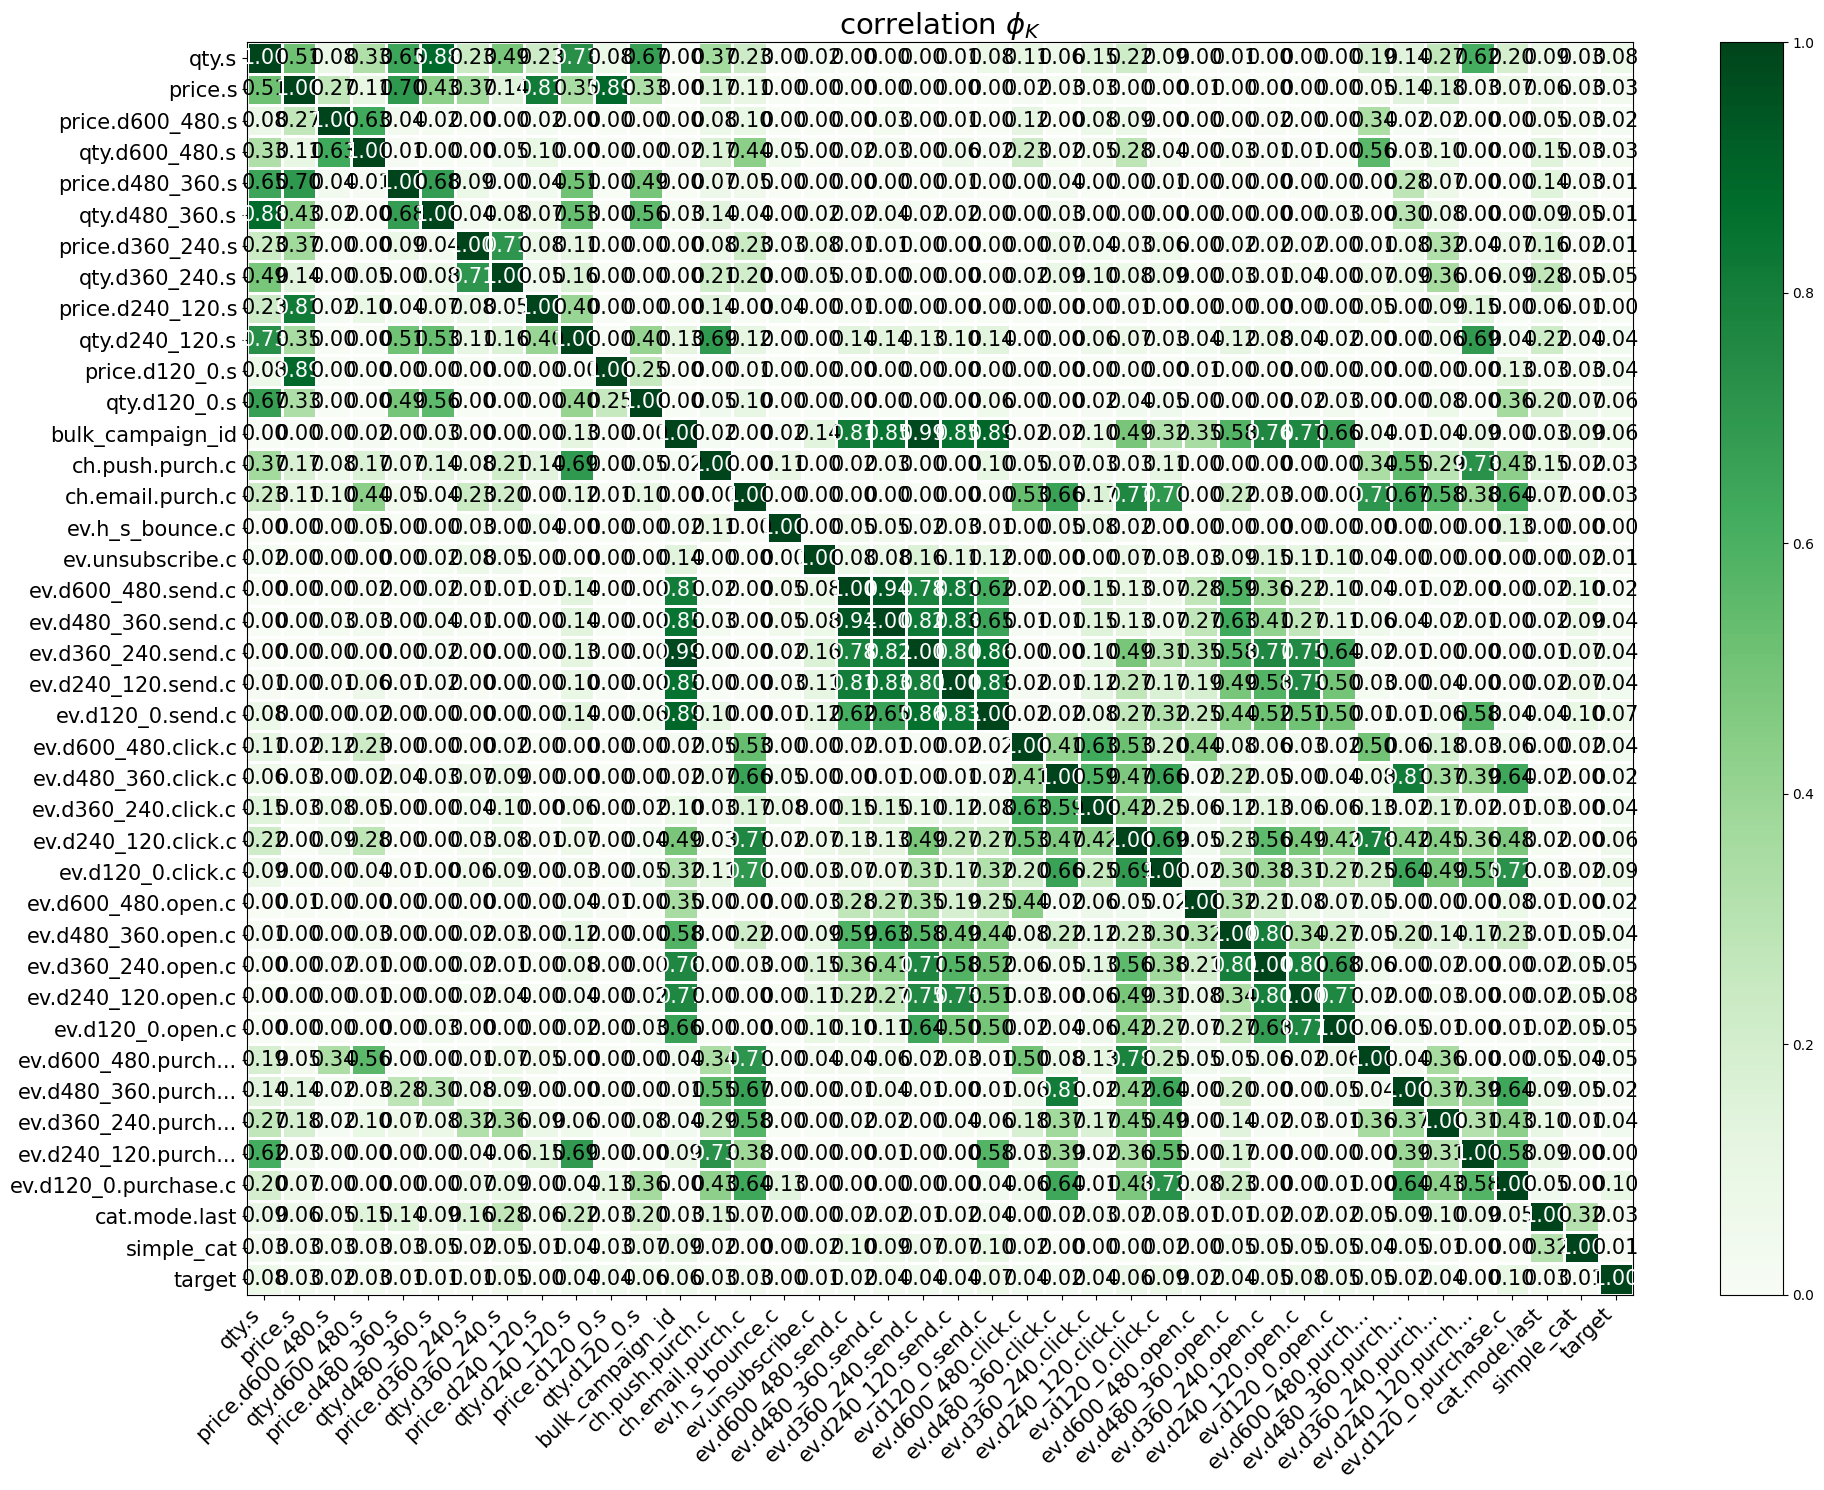

In [136]:
phik_overview = phik_matrix(df_save_memory.drop(columns=id_columns), interval_cols=interval_cols)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Заметки**

 - Есть мультиколлинеарность между рядом признаков, однаок это признаки поведения пользователя в разные периоды времени.
 - Выраженного влияния на целевой признак нет.

## Обучение модели

In [219]:
df_save_memory.columns.to_list()

['client_id',
 'target',
 'simple_cat',
 'cat.mode.last',
 'ev.d120_0.purchase.c',
 'ev.d240_120.purchase.c',
 'ev.d360_240.purchase.c',
 'ev.d480_360.purchase.c',
 'ev.d600_480.purchase.c',
 'ev.d120_0.open.c',
 'ev.d240_120.open.c',
 'ev.d360_240.open.c',
 'ev.d480_360.open.c',
 'ev.d600_480.open.c',
 'ev.d120_0.click.c',
 'ev.d240_120.click.c',
 'ev.d360_240.click.c',
 'ev.d480_360.click.c',
 'ev.d600_480.click.c',
 'ev.d120_0.send.c',
 'ev.d240_120.send.c',
 'ev.d360_240.send.c',
 'ev.d480_360.send.c',
 'ev.d600_480.send.c',
 'ev.unsubscribe.c',
 'ev.h_s_bounce.c',
 'ch.email.purch.c',
 'ch.push.purch.c',
 'bulk_campaign_id',
 'qty.d120_0.s',
 'price.d120_0.s',
 'qty.d240_120.s',
 'price.d240_120.s',
 'qty.d360_240.s',
 'price.d360_240.s',
 'qty.d480_360.s',
 'price.d480_360.s',
 'qty.d600_480.s',
 'price.d600_480.s',
 'price.s',
 'qty.s']

In [302]:
target_feature = 'target'

ohe_columns = [
    'simple_cat',
    'cat.mode.last'
]

num_columns = [
    # 'ev.d120_0.purchase.c',
    # 'ev.d240_120.purchase.c',
    # 'ev.d360_240.purchase.c',
    # 'ev.d480_360.purchase.c',
    # 'ev.d600_480.purchase.c',
    'ev.d120_0.open.c',
    'ev.d240_120.open.c',
    'ev.d360_240.open.c',
    'ev.d480_360.open.c',
    # 'ev.d600_480.open.c',
    'ev.d120_0.click.c',
    'ev.d240_120.click.c',
    'ev.d360_240.click.c',
    'ev.d480_360.click.c',
    # 'ev.d600_480.click.c',
    'ev.d120_0.send.c',
    'ev.d240_120.send.c',
    'ev.d360_240.send.c',
    'ev.d480_360.send.c',
    # 'ev.d600_480.send.c',
    # 'ev.unsubscribe.c',
    # 'ev.h_s_bounce.c',
    # 'ch.email.purch.c',
    # 'ch.push.purch.c',
    'bulk_campaign_id',
    'qty.d120_0.s',
    'price.d120_0.s',
    'qty.d240_120.s',
    'price.d240_120.s',
    'qty.d360_240.s',
    'price.d360_240.s',
    'qty.d480_360.s',
    'price.d480_360.s',
    # 'qty.d600_480.s',
    # 'price.d600_480.s',
    'price.s',
    'qty.s'
]

drop_features = [
    'ev.d120_0.purchase.c',
    'ev.d240_120.purchase.c',
    'ev.d360_240.purchase.c',
    'ev.d480_360.purchase.c',
    'ev.unsubscribe.c',
    'ev.h_s_bounce.c',
    'ch.email.purch.c',
    'ch.push.purch.c',
    'ev.d600_480.purchase.c',
    'ev.d600_480.open.c',
    'ev.d600_480.click.c',
    'ev.d600_480.send.c',
    'qty.d600_480.s',
    'price.d600_480.s',
]

In [303]:
ohe_pipe = Pipeline(
    [
        (
            'ohe', 
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
        )
    ]
)

In [304]:
# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

In [305]:
# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', CatBoostClassifier(random_state=RANDOM_STATE))
])

In [314]:
# создаём словарь с гиперпараметрами для каждой модели
param_grid = [
    # {
    #     'models': [CatBoostClassifier(
    #         random_state=RANDOM_STATE
    #     )],
    #     'models__iterations': [100, 200],
    #     'models__learning_rate': [0.1],
    #     'models__depth': [10]
    # },
    # {
    #     'models': [RandomForestClassifier(
    #         random_state=RANDOM_STATE
    #     )],
    #     'models__n_estimators': [100, 200],
    #     'models__max_depth': [10]
    # },
    {
        'models': [LGBMClassifier(
            class_weight='balanced',
            is_unbalance=True,
            # scale_pos_weight=49,
            # subsample=0.8,
            # colsample_bytree=0.8,
            # reg_alpha=0.1,
            # reg_lambda=0.1,
            verbose=-1,
            random_state=RANDOM_STATE
        )],
        'models__n_estimators': [500],
        'models__learning_rate': [0.1],
        'models__max_depth': [20],
        'models__num_leaves': [16]
    },
]

In [315]:
X_train, X_test, y_train, y_test = train_test_split(
    df_save_memory.drop(drop_features, axis=1),
    df_save_memory[target_feature], 
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = df_save_memory[target_feature]
)

In [316]:
X_train.shape, y_train.shape

((39879, 27), (39879,))

In [317]:
X_test.shape, y_test.shape

((9970, 27), (9970,))

In [318]:
grid = GridSearchCV(
    pipe_final, 
    param_grid=param_grid, 
    cv=5, 
    scoring='roc_auc',
    n_jobs=-1
)

In [319]:
grid.fit(X_train, y_train)

/home/n1654/jupyter-notebook/jupyter-env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/n1654/jupyter-notebook/jupyter-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/n1654/jupyter-notebook/jupyter-env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/n1654/jupyter-notebook/jupyter-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/n1654/jupyter-notebook/jupyter-env/lib/python3.12/

,estimator,Pipeline(step...0508b7f0b0>)])
,param_grid,"[{'models': [LGBMClassifie... verbose=-1)], 'models__learning_rate': [0.1], 'models__max_depth': [20], 'models__n_estimators': [500], ...}]"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ohe', ...), ('num', ...)]"


In [320]:
print('Лучшая модель и её параметры:\n\n', grid.best_estimator_)
print('Метрика лучшей модели на тренировочной выборке:', grid.best_score_)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['simple_cat',
                                                   'cat.mode.last']),
                                                 ('num', MinMaxScaler(),
                                                  ['ev.d120_0.open.c',
                                                   'ev.d240_120.open.c',
                                                   'ev.d360_240.open.c',
            

In [321]:
# проверим работу модели на тестовой выборке
y_test_pred = grid.predict(X_test)
print(f'ROC_AUC: {roc_auc_score(y_test, y_test_pred)}')

ROC_AUC: 1.0


/home/n1654/jupyter-notebook/jupyter-env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros

/home/n1654/jupyter-notebook/jupyter-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



## Выводы

 - Качество модели на метрике ROC-AUC достаточно низкое:
     - ROC-AUC на тренировочной выборке: 0.62
     - ROC-AUC на тестовой выборке: 0.61
 - Модель не переобучена
 - Для бизнеса использование не рекомендуется, качество предсказаний на ~11% лучше случайных